In [1]:
import os
import random

import cv2
import matplotlib
from mpl_toolkits.mplot3d import axes3d  # needed for 3d projection in some cases
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import skimage.feature
import skimage.filters
import skimage.measure
import skimage.segmentation

In [2]:
matplotlib.rcParams['figure.figsize'] = 12, 6

# Overlapping objects

Example from `scikit-image` library: [https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_watershed.html](https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_watershed.html)

In [3]:
# Generate an initial image with two overlapping circles
X, Y = np.indices((80, 80))
xc1, yc1 = 28, 28
xc2, yc2 = 44, 52
r1, r2 = 16, 20
mask_circle1 = (X - xc1) ** 2 + (Y - yc1) ** 2 < r1 ** 2
mask_circle2 = (X - xc2) ** 2 + (Y - yc2) ** 2 < r2 ** 2

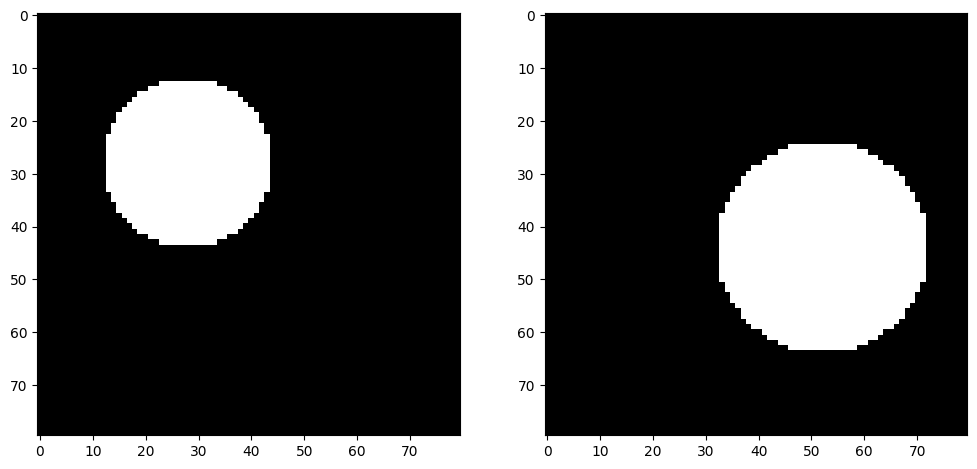

In [4]:
plt.subplot(1, 2, 1)
plt.imshow(mask_circle1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(mask_circle2, cmap='gray');

In [5]:
toy_bin = 255 * np.uint8(mask_circle1 + mask_circle2)

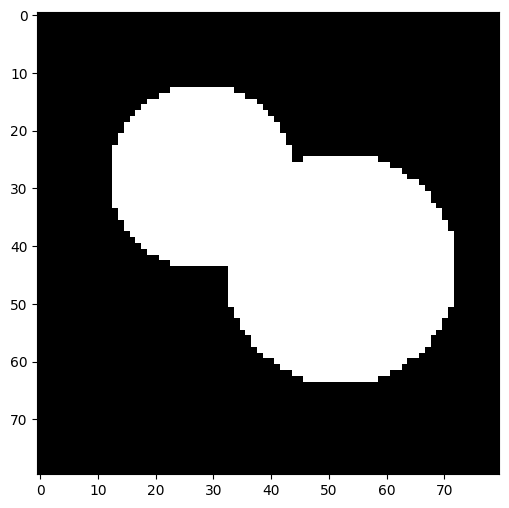

In [6]:
plt.imshow(toy_bin, cmap='gray');

In [7]:
label_image = skimage.measure.label(toy_bin)
reg_props = skimage.measure.regionprops(label_image)
len(reg_props)

1

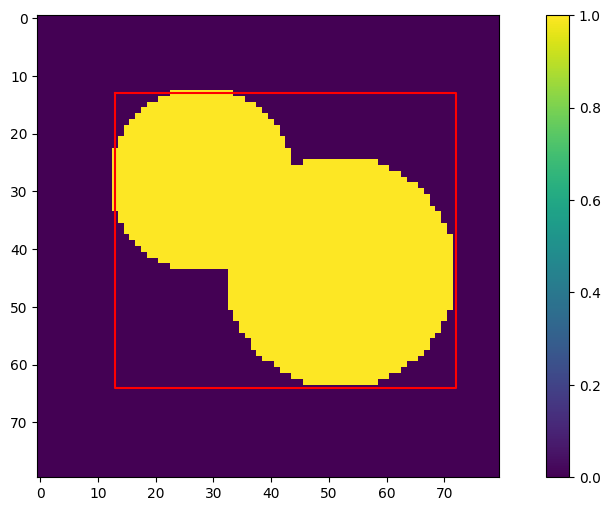

In [8]:
plt.imshow(label_image);
plt.colorbar();
for rp in reg_props:
    y1, x1, y2, x2 = rp.bbox
    plt.plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], '-r')

# Watershed segmentation

In [9]:
%%time

toy_dist = scipy.ndimage.distance_transform_edt(toy_bin)
toy_dist.shape, toy_dist.min(), toy_dist.max()

CPU times: total: 0 ns
Wall time: 1e+03 µs


((80, 80), 0.0, 20.0)

In [10]:
%%time

toy_lmax_coords = skimage.feature.peak_local_max(toy_dist)
toy_lmax_coords

CPU times: total: 0 ns
Wall time: 3 ms


array([[44, 52],
       [28, 28]], dtype=int64)

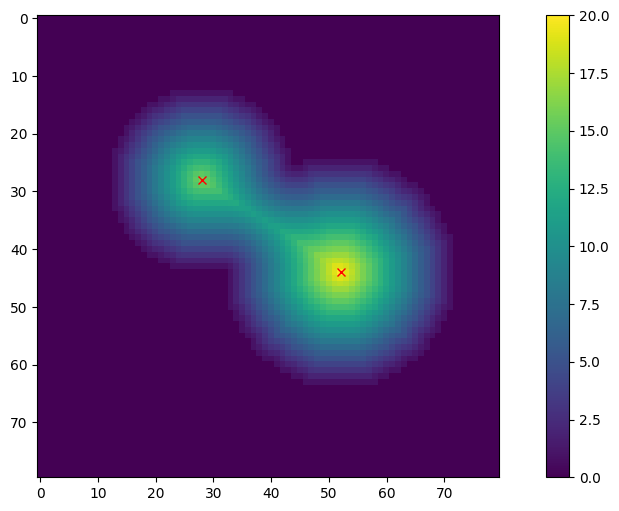

In [11]:
plt.imshow(toy_dist)
plt.plot(toy_lmax_coords[:, 1], toy_lmax_coords[:, 0], 'rx')
plt.colorbar();

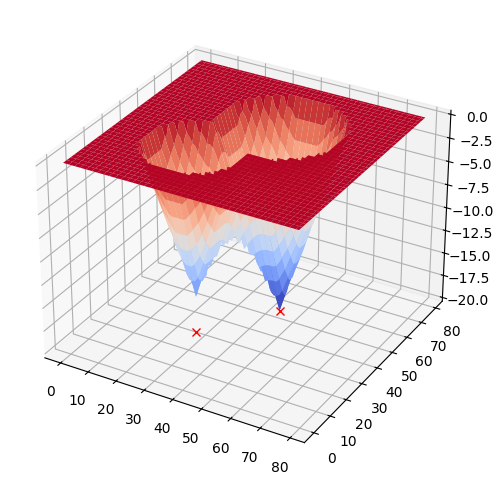

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, -toy_dist, cmap='coolwarm', antialiased=True)
ax.plot(toy_lmax_coords[:, 0], toy_lmax_coords[:, 1], 'rx', zs=min(ax.get_zlim()));

In [13]:
toy_markers = np.zeros_like(toy_bin)
toy_markers[toy_lmax_coords[:, 0], toy_lmax_coords[:, 1]] = 1 + np.arange(toy_lmax_coords.shape[0])

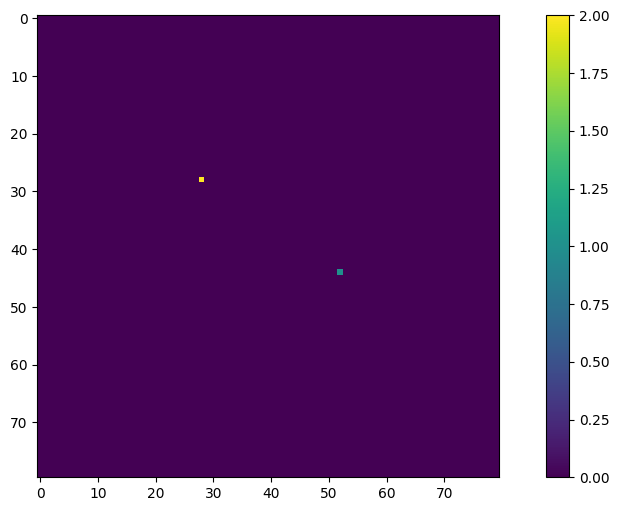

In [14]:
plt.imshow(toy_markers);
plt.colorbar();

In [15]:
%%time

toy_labels = skimage.segmentation.watershed(-toy_dist, toy_markers, mask=toy_bin)

CPU times: total: 0 ns
Wall time: 1 ms


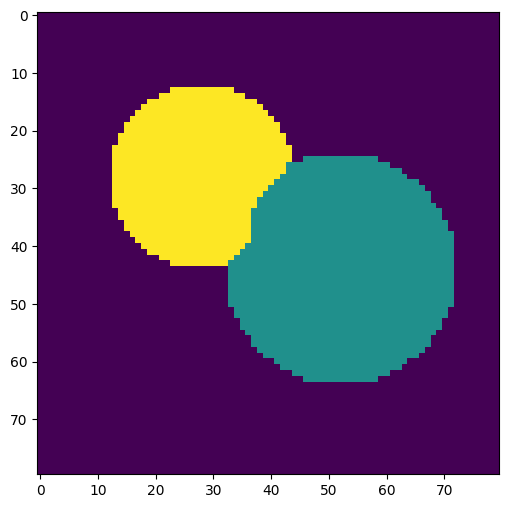

In [16]:
plt.imshow(toy_labels);

## Real world example

In [17]:
coins_rgb = cv2.imread('../data/water_coins.jpg')[..., ::-1]
coins_gray = cv2.cvtColor(coins_rgb, cv2.COLOR_RGB2GRAY)

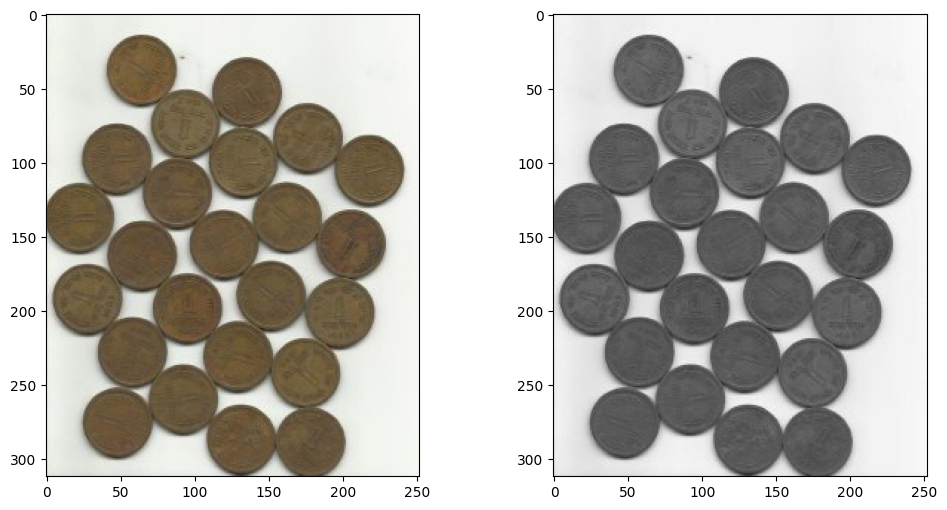

In [18]:
plt.subplot(1, 2, 1)
plt.imshow(coins_rgb)
plt.subplot(1, 2, 2)
plt.imshow(coins_gray, cmap='gray', vmin=0, vmax=255);

In [19]:
%%time

thresh_val, coins_bin = cv2.threshold(coins_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

CPU times: total: 0 ns
Wall time: 0 ns


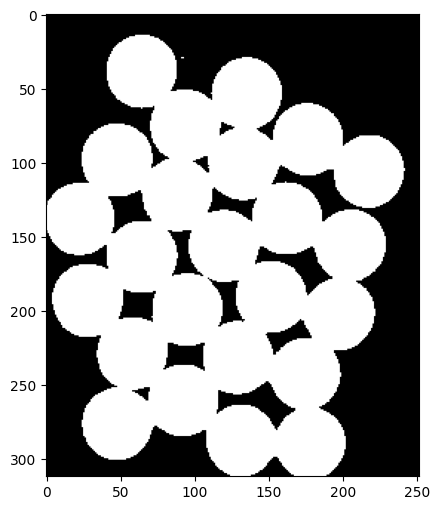

In [20]:
plt.imshow(coins_bin, cmap='gray');

In [21]:
%%time

coins_dist = scipy.ndimage.distance_transform_edt(coins_bin)
coins_dist.dtype, coins_dist.min(), coins_dist.max()

CPU times: total: 0 ns
Wall time: 4.22 ms


(dtype('float64'), 0.0, 24.0)

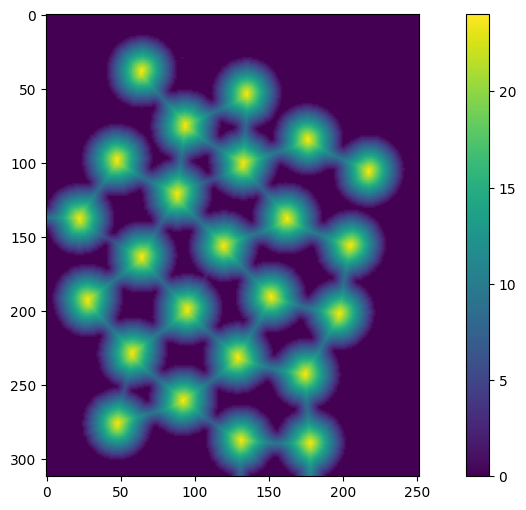

In [22]:
plt.imshow(coins_dist);
plt.colorbar();

In [23]:
%%time

coins_lmaxs = skimage.feature.peak_local_max(coins_dist, min_distance=5)
coins_markers = np.zeros_like(coins_bin)
coins_markers[coins_lmaxs[:, 0], coins_lmaxs[:, 1]] = 1 + np.arange(coins_lmaxs.shape[0])
coins_lmaxs.shape

CPU times: total: 0 ns
Wall time: 3.04 ms


(25, 2)

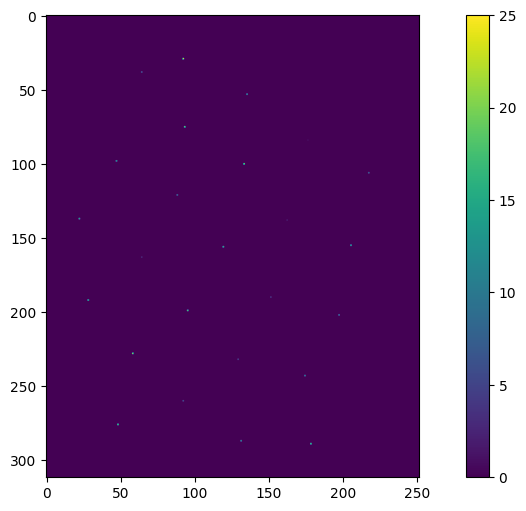

In [24]:
plt.imshow(coins_markers);
plt.colorbar();

In [25]:
%%time

coins_labels = skimage.segmentation.watershed(-coins_dist, markers=coins_markers, mask=coins_bin)

CPU times: total: 0 ns
Wall time: 6 ms


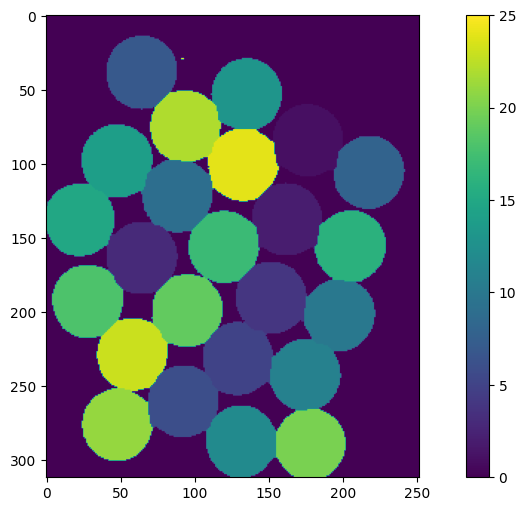

In [26]:
plt.imshow(coins_labels);
plt.colorbar();

In [27]:
coins_reg_props = skimage.measure.regionprops(coins_labels)
len(coins_reg_props)

25

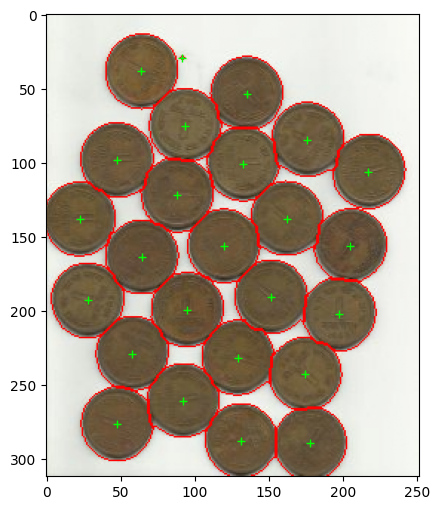

In [28]:
plt.imshow(skimage.segmentation.mark_boundaries(coins_rgb, coins_labels, color=(1, 0, 0)));
for i, rp in enumerate(coins_reg_props):
    plt.plot(rp.centroid[1], rp.centroid[0], '+', color=(0, 1, 0))
#     plt.plot(coins_lmaxs[i, 1], coins_lmaxs[i, 0], 'bx')

# Watershed in OpenCV

Example: [https://docs.opencv.org/master/d3/db4/tutorial_py_watershed.html](https://docs.opencv.org/master/d3/db4/tutorial_py_watershed.html)

In [29]:
%%time

coins_opened = cv2.morphologyEx(
    coins_bin,
    cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
)

CPU times: total: 0 ns
Wall time: 1 ms


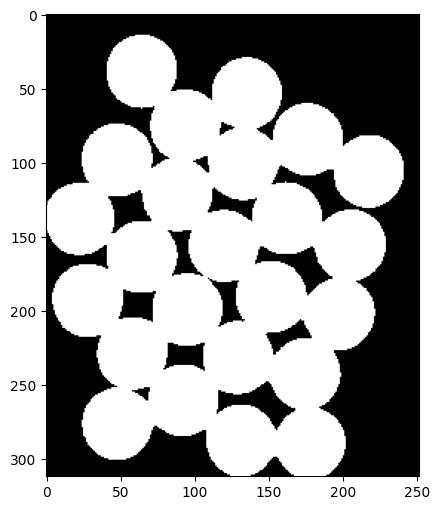

In [30]:
plt.imshow(coins_opened, cmap='gray');

In [31]:
%%time

coins_sure_fg = cv2.morphologyEx(
    coins_opened,
    cv2.MORPH_ERODE,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)),
    iterations=3
)

CPU times: total: 0 ns
Wall time: 1.05 ms


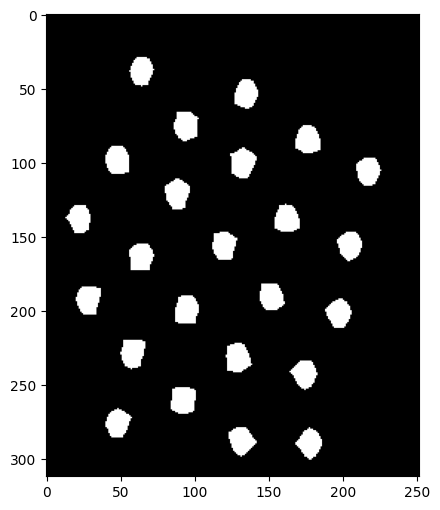

In [32]:
plt.imshow(coins_sure_fg, cmap='gray');

In [33]:
%%time

coins_sure_bg = 255 - cv2.morphologyEx(  # notice the inverse
    coins_opened,
    cv2.MORPH_DILATE,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
)

CPU times: total: 0 ns
Wall time: 0 ns


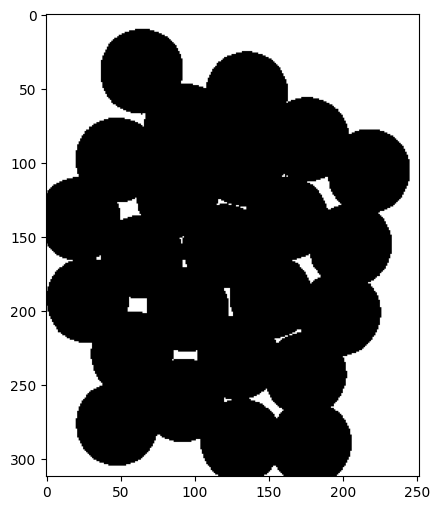

In [34]:
# white is the sure background
plt.imshow(coins_sure_bg, cmap='gray');

In [35]:
ret, coins_markers_cv = cv2.connectedComponents(coins_sure_fg)
ret

25

In [36]:
# set background to one instead of zero
coins_markers_cv += 1

In [37]:
# everything that's neither foreground nor background label as zero
coins_markers_cv[~np.logical_or(coins_sure_fg > 0, coins_sure_bg > 0)] = 0

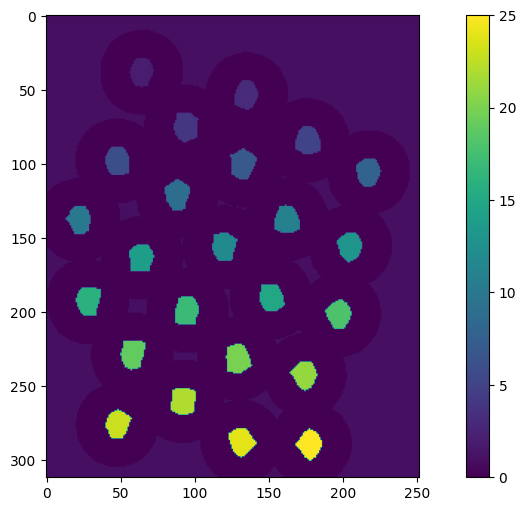

In [38]:
plt.imshow(coins_markers_cv)
plt.colorbar();

In [39]:
%%time

# apply on the RGB image, not on the distance transform
# NOTE: OpenCV is actually gonna write the results inplace into the `markers` argument, hence the `.copy()`
coins_labels_cv = cv2.watershed(coins_rgb, coins_markers_cv.copy())

CPU times: total: 0 ns
Wall time: 3 ms


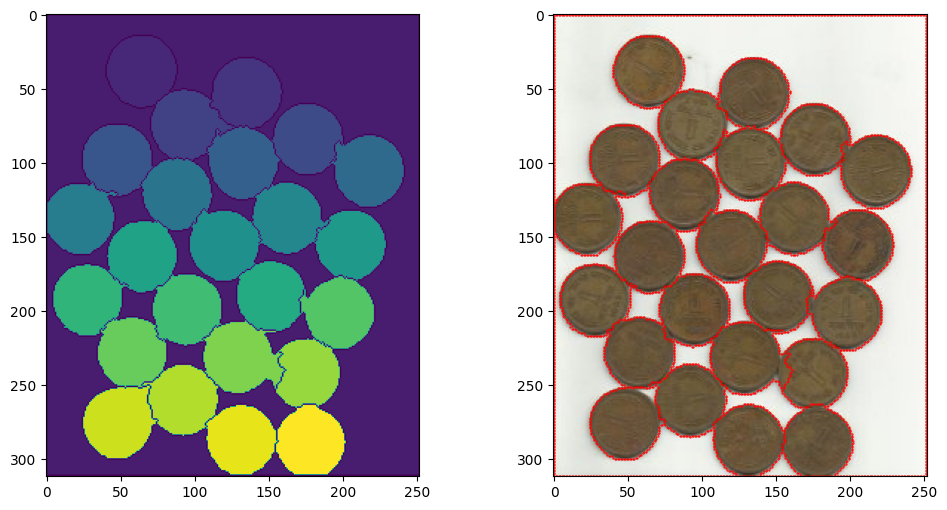

In [40]:
plt.subplot(1, 2, 1)
plt.imshow(coins_labels_cv)
plt.subplot(1, 2, 2)
plt.imshow(coins_rgb);
plt.plot(*np.argwhere(coins_labels_cv == -1).T[::-1], '.', color=(1, 0, 0), markersize=1);
# plt.imshow(skimage.segmentation.mark_boundaries(coins_rgb, coins_labels_cv, color=(1, 0, 0)));

## Distance image does not work in OpenCV

Input to the `watershed` function must be three channel uint8 image, from which it automatically extracts edges via gradients.

In [41]:
coins_dist_cv = cv2.distanceTransform(coins_opened, cv2.DIST_L2, 5)
coins_dist_cv.dtype, coins_dist_cv.shape, coins_dist_cv.min(), coins_dist_cv.max()

(dtype('float32'), (312, 252), 0.0, 23.968996)

In [42]:
coins_dist_cv_normed = 255 - 255 * cv2.normalize(coins_dist_cv, None, norm_type=cv2.NORM_MINMAX)
coins_dist_cv_normed = coins_dist_cv_normed.astype(np.uint8)
coins_dist_cv_normed = np.stack((coins_dist_cv_normed, coins_dist_cv_normed, coins_dist_cv_normed)).transpose(1, 2, 0)
coins_dist_cv_normed.dtype, coins_dist_cv_normed.shape, coins_dist_cv_normed.min(), coins_dist_cv_normed.max()

(dtype('uint8'), (312, 252, 3), 0, 255)

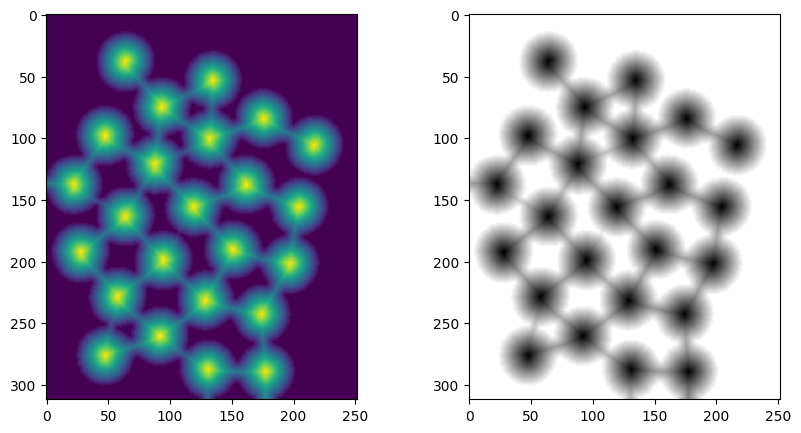

In [43]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(coins_dist_cv)
plt.subplot(1, 2, 2)
plt.imshow(coins_dist_cv_normed);

In [44]:
%%time

coins_labels_cv_n = cv2.watershed(coins_dist_cv_normed, coins_markers_cv.copy())

CPU times: total: 0 ns
Wall time: 2 ms


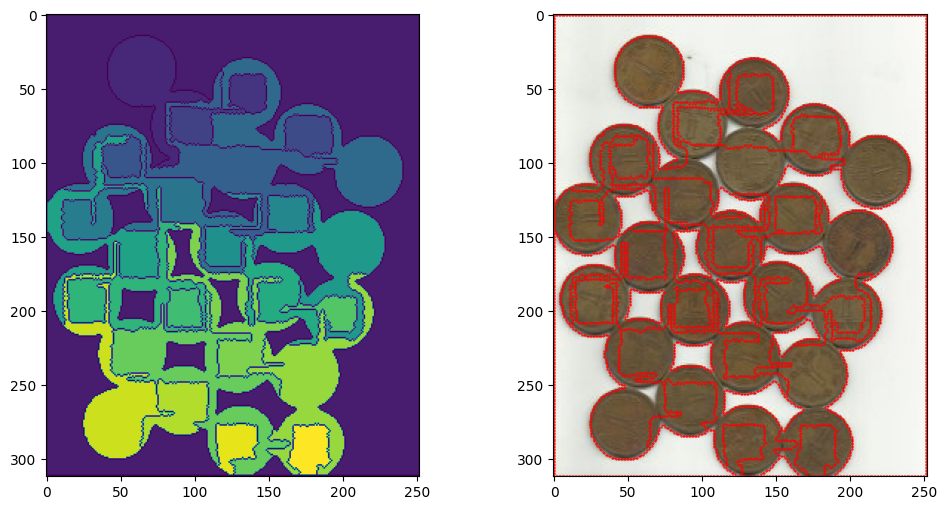

In [45]:
plt.subplot(1, 2, 1)
plt.imshow(coins_labels_cv_n)
plt.subplot(1, 2, 2)
plt.imshow(coins_rgb);
plt.plot(*np.argwhere(coins_labels_cv_n == -1).T[::-1], '.', color=(1, 0, 0), markersize=1);

## Improve by smoothing the image

In [46]:
coins_rgb_smooth = cv2.bilateralFilter(coins_rgb, 9, 75, 75)

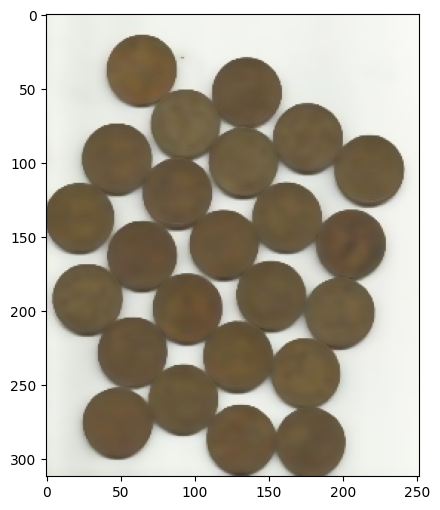

In [47]:
plt.imshow(coins_rgb_smooth);

In [48]:
%%time

coins_labels_cv_smooth = cv2.watershed(coins_rgb_smooth, coins_markers_cv.copy())

CPU times: total: 0 ns
Wall time: 2 ms


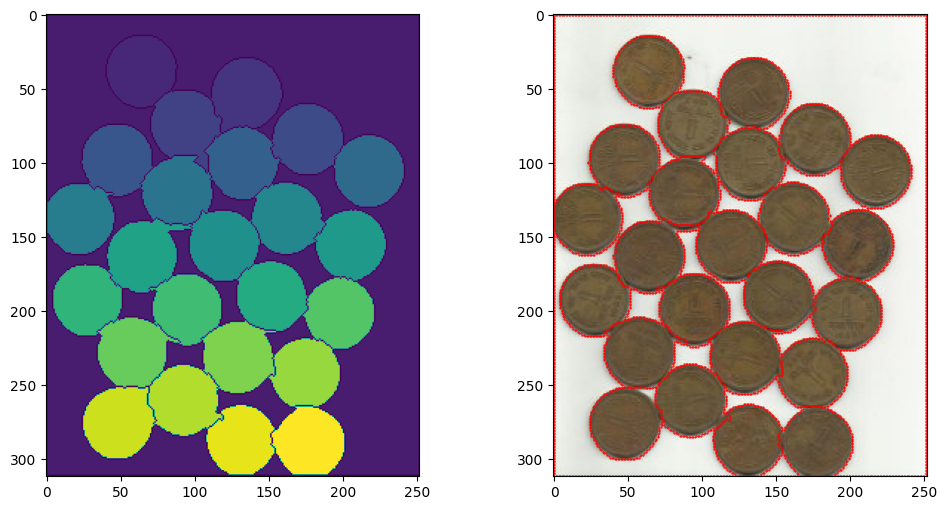

In [49]:
plt.subplot(1, 2, 1)
plt.imshow(coins_labels_cv_smooth)
plt.subplot(1, 2, 2)
plt.imshow(coins_rgb);
plt.plot(*np.argwhere(coins_labels_cv_smooth == -1).T[::-1], '.', color=(1, 0, 0), markersize=1);

# Superpixels: image oversegmentation

- Example: [https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_segmentations.html](https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_segmentations.html)

In [50]:
fruits_rgb = cv2.imread('../data/fruits.jpg')[..., ::-1]
fruits_gray = cv2.cvtColor(fruits_rgb, cv2.COLOR_RGB2GRAY)

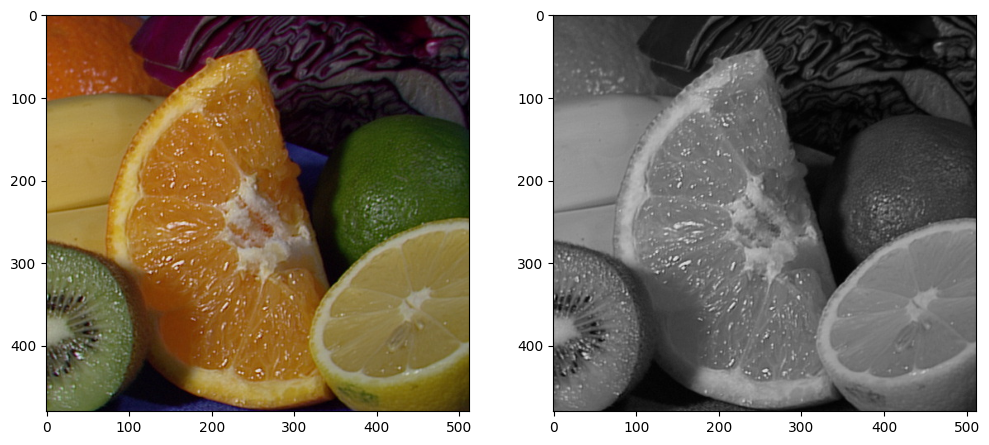

In [51]:
plt.subplot(1, 2, 1)
plt.imshow(fruits_rgb)
plt.subplot(1, 2, 2)
plt.imshow(fruits_gray, cmap='gray', vmin=0, vmax=255);

In [52]:
%%time

fruits_sobel_mag = skimage.filters.sobel(fruits_gray)

CPU times: total: 15.6 ms
Wall time: 11 ms


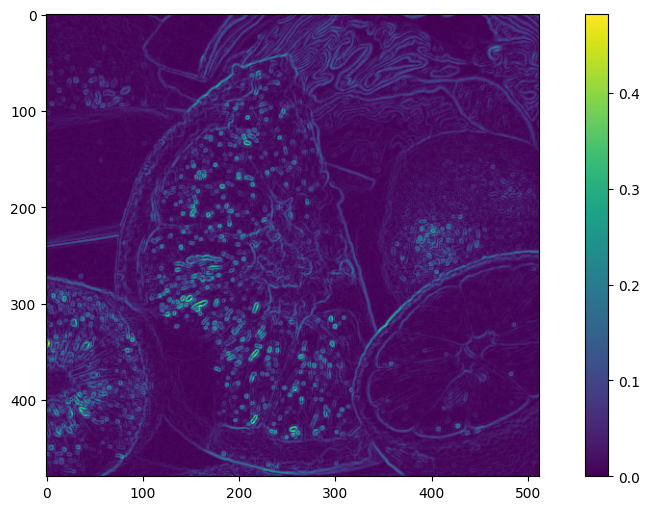

In [53]:
plt.imshow(fruits_sobel_mag);
plt.colorbar();

In [54]:
%%time

fruits_ss_watershed = skimage.segmentation.watershed(fruits_sobel_mag, markers=144)

CPU times: total: 46.9 ms
Wall time: 38.2 ms


In [55]:
%%time

# Description of SLIC superpixels e.g. at https://www.youtube.com/watch?v=uDhcpwxCufU
fruits_ss_slic = skimage.segmentation.slic(fruits_rgb, n_segments=144, compactness=10, sigma=1, start_label=1)

CPU times: total: 188 ms
Wall time: 191 ms


In [56]:
%%time

# Description of Quickshift superpixels e.g. at https://www.vlfeat.org/api/quickshift.html
fruits_ss_quick = skimage.segmentation.quickshift(fruits_rgb, ratio=0.8, kernel_size=7, max_dist=100)

CPU times: total: 4.16 s
Wall time: 4.13 s


In [57]:
%%time

# Description of Felzenswalb's superpixels e.g. at https://www.analyticsvidhya.com/blog/2021/05/image-segmentation-with-felzenszwalbs-algorithm/
fruits_ss_felzenswalb = skimage.segmentation.felzenszwalb(fruits_rgb, scale=100, sigma=1.5, min_size=75)

CPU times: total: 578 ms
Wall time: 571 ms


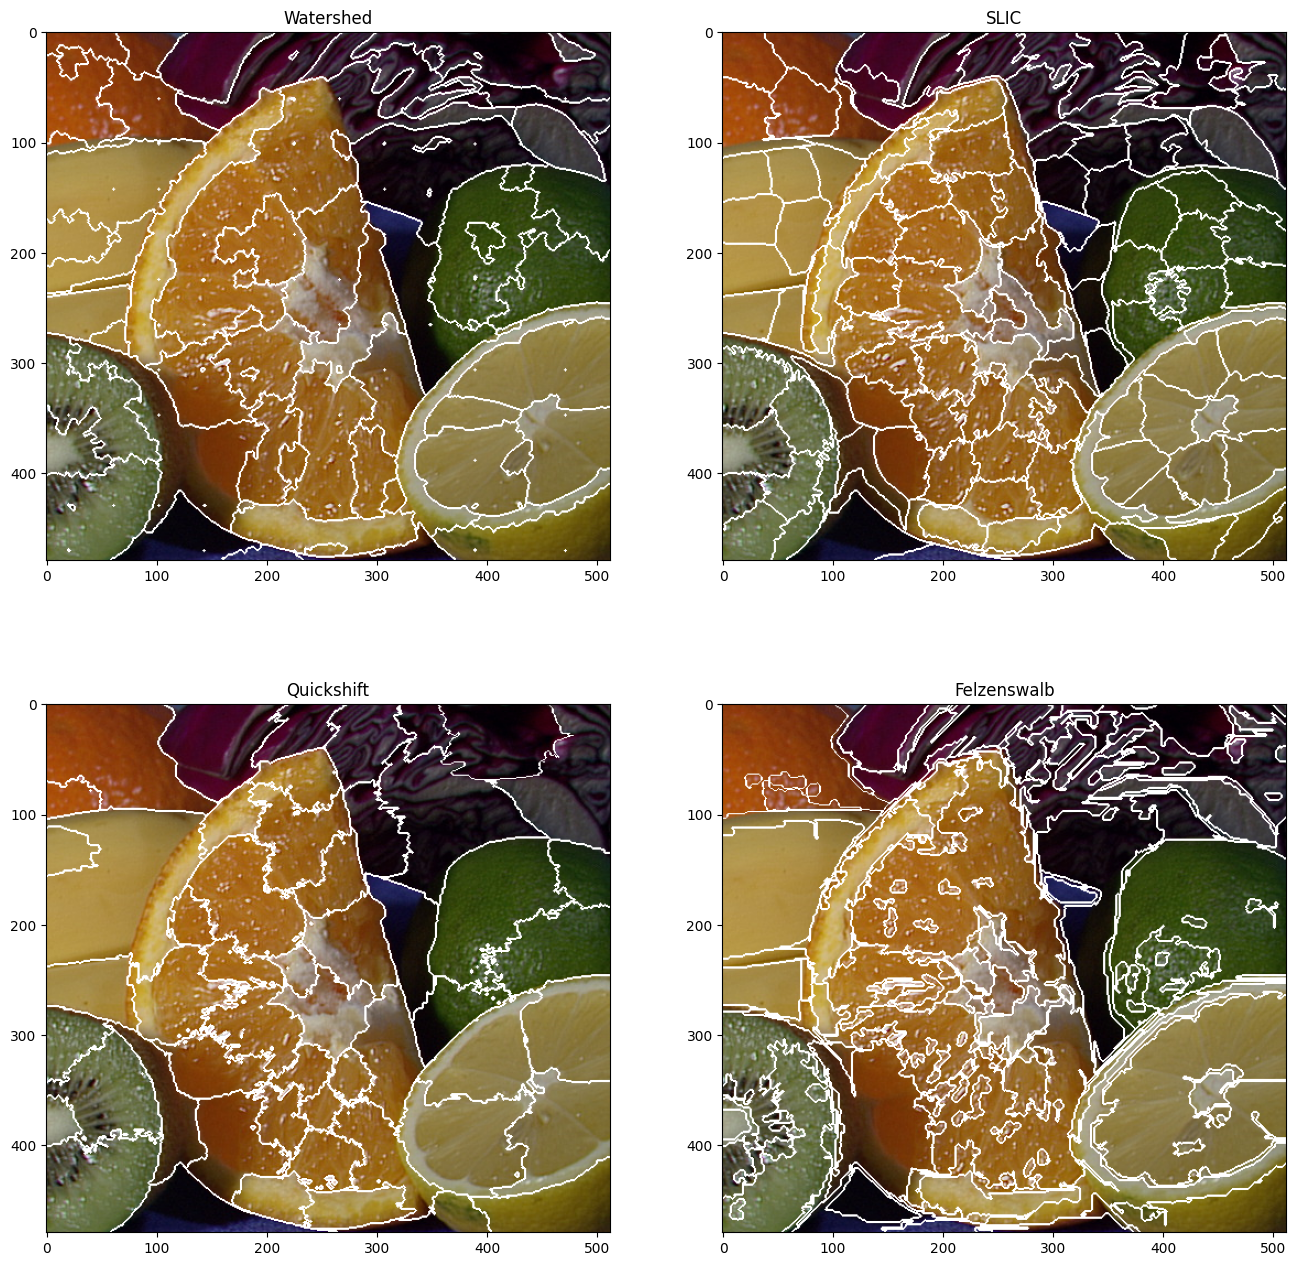

In [58]:
plt.figure(figsize=(16, 16))
plt.subplot(2, 2, 1)
plt.imshow(skimage.segmentation.mark_boundaries(fruits_rgb, fruits_ss_watershed, color=(1, 1, 1)))
plt.title('Watershed')
plt.subplot(2, 2, 2)
plt.imshow(skimage.segmentation.mark_boundaries(fruits_rgb, fruits_ss_slic, color=(1, 1, 1)))
plt.title('SLIC')
plt.subplot(2, 2, 3)
plt.imshow(skimage.segmentation.mark_boundaries(fruits_rgb, fruits_ss_quick, color=(1, 1, 1)))
plt.title('Quickshift')
plt.subplot(2, 2, 4)
plt.imshow(skimage.segmentation.mark_boundaries(fruits_rgb, fruits_ss_felzenswalb, color=(1, 1, 1)))
plt.title('Felzenswalb');

# GrabCut: supervised segmentation

Example: [https://docs.opencv.org/3.4/d8/d83/tutorial_py_grabcut.html](https://docs.opencv.org/3.4/d8/d83/tutorial_py_grabcut.html)

In [59]:
messi_rgb = cv2.imread('../data/messi5.jpg')[..., ::-1]

In [60]:
# init rectange in xywh format
rx, ry, rw, rh = 50, 50, 450, 290

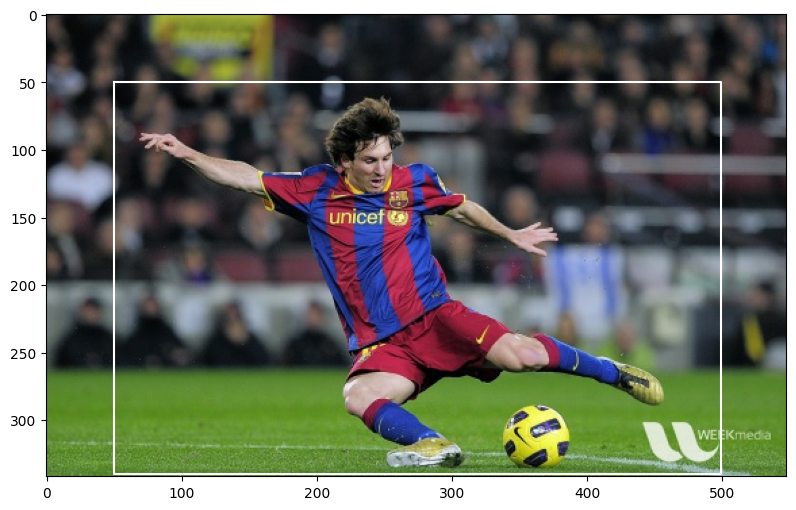

In [61]:
plt.imshow(messi_rgb);
plt.plot([rx, rx + rw - 1, rx + rw - 1, rx, rx], [ry, ry, ry + rh, ry + rh, ry], '-w');

In [62]:
%%time

messi_mask_r, messi_bg_mdl_r, messi_fg_mdl_r = cv2.grabCut(messi_rgb, None, (rx, ry, rw, rh), None, None, 5, mode=cv2.GC_INIT_WITH_RECT)

CPU times: total: 1.52 s
Wall time: 1.27 s


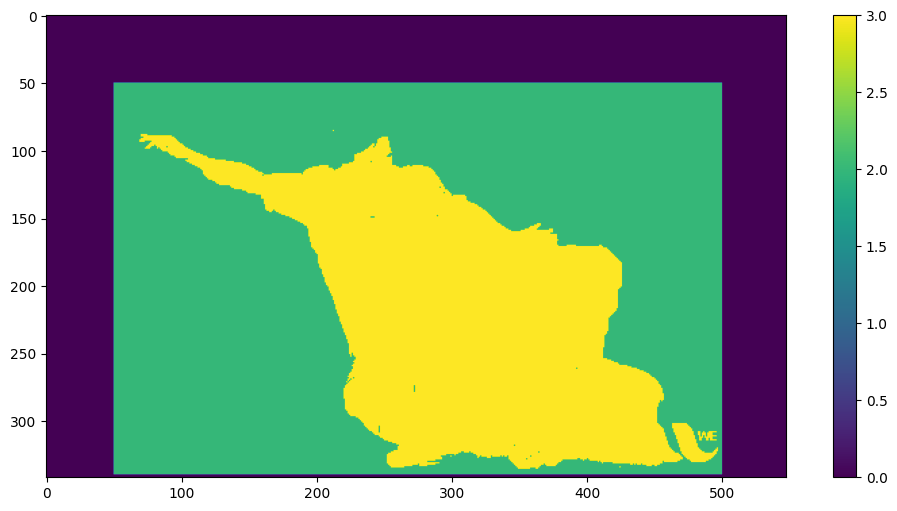

In [63]:
plt.imshow(messi_mask_r)
plt.colorbar();

In [64]:
cv2.GC_BGD, cv2.GC_FGD, cv2.GC_PR_BGD, cv2.GC_PR_FGD

(0, 1, 2, 3)

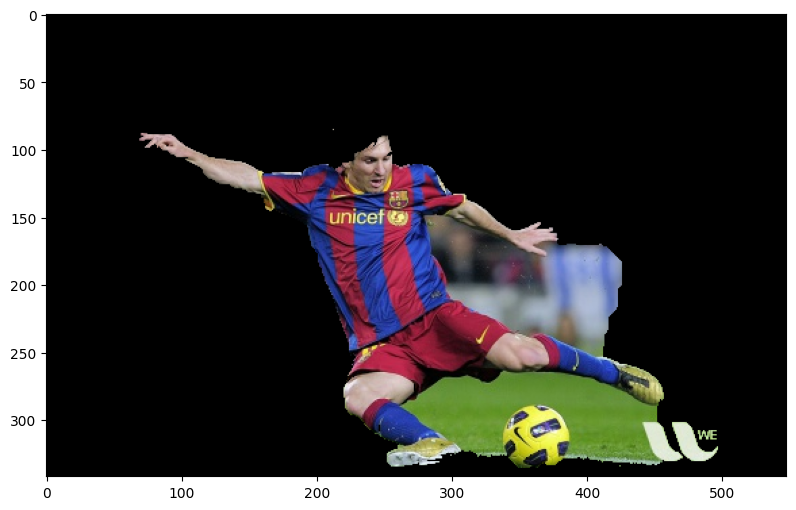

In [65]:
plt.imshow((messi_mask_r == cv2.GC_PR_FGD)[..., None] * messi_rgb);

In [66]:
messi_markers = cv2.imread('../data/messi5_markers.png', flags=cv2.IMREAD_UNCHANGED)
messi_markers.shape, np.unique(messi_markers)

((342, 548), array([0, 1, 2], dtype=uint8))

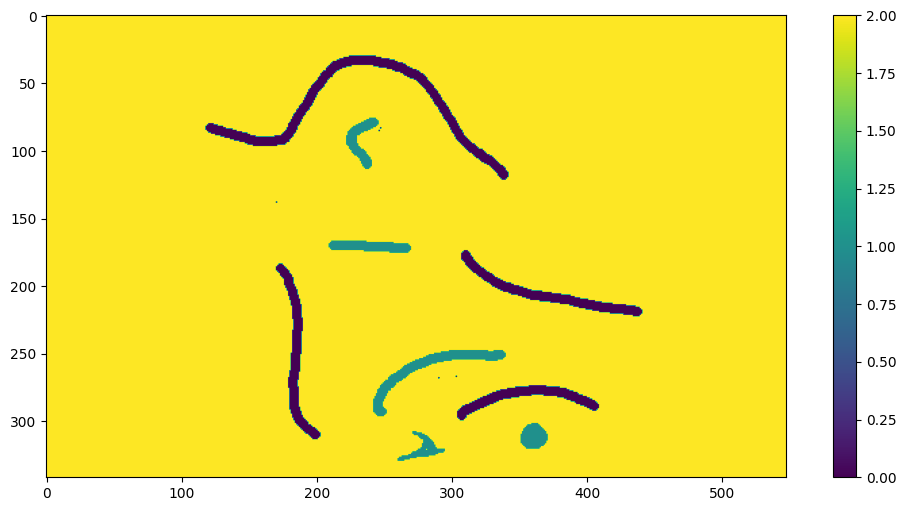

In [67]:
plt.imshow(messi_markers);
plt.colorbar();

In [68]:
%%time

messi_mask_m, messi_bg_mdl_m, messi_fg_mdl_m = cv2.grabCut(messi_rgb, messi_markers.copy(), None, None, None, 5, mode=cv2.GC_INIT_WITH_MASK)

CPU times: total: 516 ms
Wall time: 374 ms


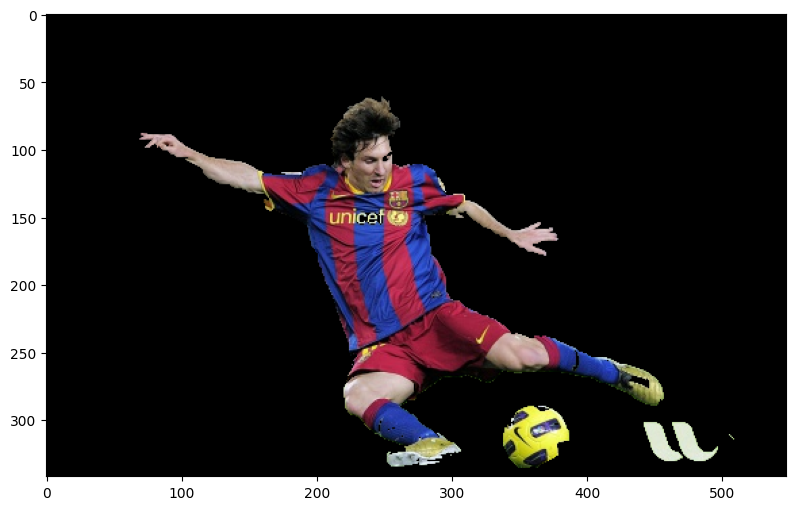

In [69]:
plt.imshow(((messi_mask_m == cv2.GC_FGD) | (messi_mask_m == cv2.GC_PR_FGD))[..., None] * messi_rgb);

# Init watershed from the same "supervised" markers

In [70]:
messi_sobel_mag = skimage.filters.sobel(cv2.cvtColor(messi_rgb, cv2.COLOR_RGB2GRAY))

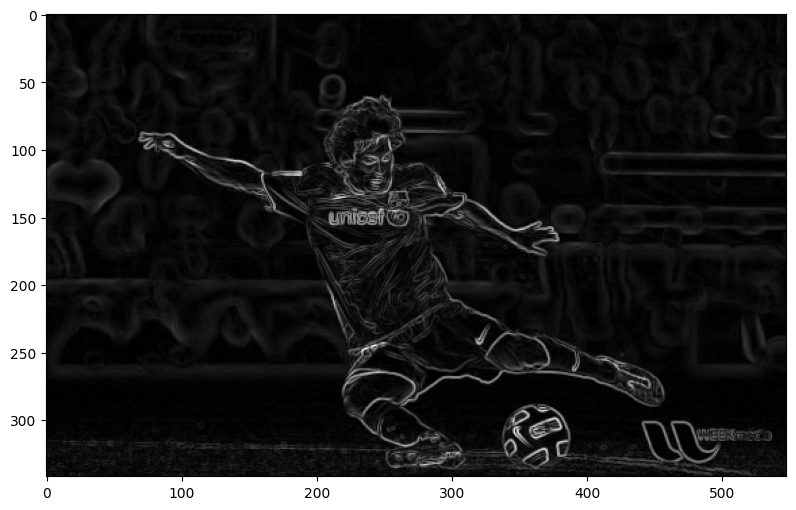

In [71]:
plt.imshow(messi_sobel_mag, cmap='gray');

In [72]:
messi_markers_w = messi_markers.copy()
messi_markers_w[messi_markers==cv2.GC_PR_BGD] = 0
messi_markers_w[messi_markers==cv2.GC_BGD] = 1
messi_markers_w[messi_markers==cv2.GC_FGD] = 2

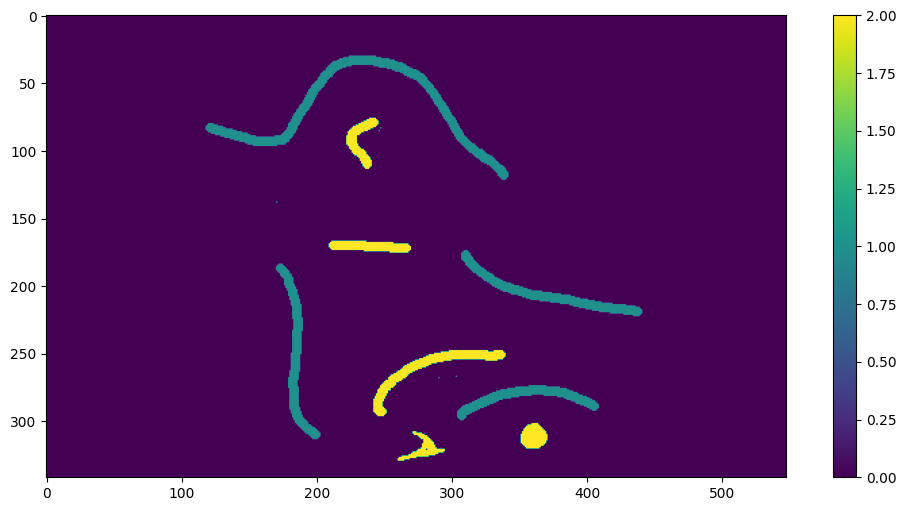

In [73]:
plt.imshow(messi_markers_w)
plt.colorbar();

In [74]:
messi_labels = skimage.segmentation.watershed(messi_sobel_mag, markers=messi_markers_w)

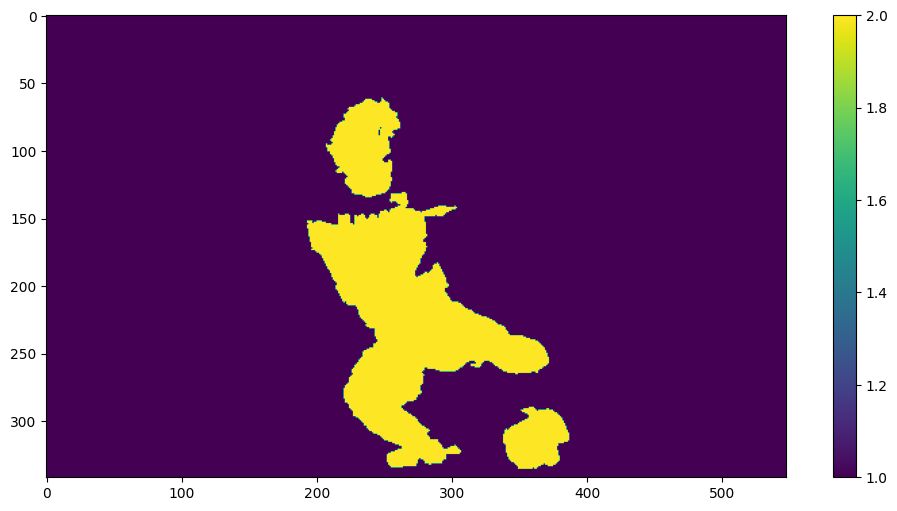

In [75]:
plt.imshow(messi_labels)
plt.colorbar();

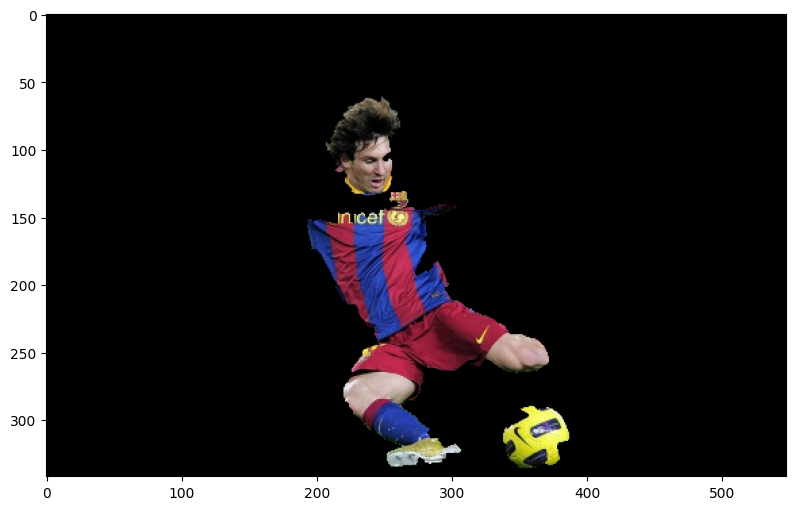

In [76]:
plt.imshow((messi_labels == 2)[..., None] * messi_rgb);

# Active contours

Example: https://scikit-image.org/docs/dev/auto_examples/edges/plot_active_contours.html

## Chan-Vese